# Visualizing clusters in surface source space

In [6]:
import mne
from mne.datasets import sample
from mne.minimum_norm import apply_inverse_epochs, read_inverse_operator
import mne_plsc

data_path = sample.data_path()
meg_path = data_path / "MEG" / "sample"
fname_inv = meg_path / "sample_audvis-meg-oct-6-meg-inv.fif"
fname_raw = meg_path / "sample_audvis_filt-0-40_raw.fif"
fname_event = meg_path / "sample_audvis_filt-0-40_raw-eve.fif"

# Load data
inverse_operator = read_inverse_operator(fname_inv)
raw = mne.io.read_raw_fif(fname_raw)
events = mne.read_events(fname_event)

# Add a bad channel
raw.info["bads"] += ["EEG 053"]  # bads + 1 more

# Create epochs
picks = mne.pick_types(
    raw.info, meg=True, eeg=False, stim=False, eog=True, exclude="bads"
)
epochs = mne.Epochs(
    raw,
    events,
    event_id={'left': 1, 'right': 2},
    tmin=-0.2, tmax=0.5,
    picks=picks,
    baseline=(None, 0),
    reject=dict(mag=4e-12, grad=4000e-13, eog=150e-6),
    preload=True,
    verbose=False
)

# Crop to small time window for speed
epochs.crop(0.05, 0.1)
labels = mne_plsc.utils.get_epoch_labels(epochs)

# Apply inverse operator
snr = 3.0
lambda2 = 1.0 / snr**2
method = "dSPM" 
stcs = apply_inverse_epochs(
    epochs,
    inverse_operator,
    lambda2,
    method,
    pick_ori="normal",
    verbose=False
)

Reading inverse operator decomposition from C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis-meg-oct-6-meg-inv.fif...
    Reading inverse operator info...
    [done]
    Reading inverse operator decomposition...
    [done]
    305 x 305 full covariance (kind = 1) found.
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Noise covariance matrix read.
    22494 x 22494 diagonal covariance (kind = 2) found.
    Source covariance matrix read.
    22494 x 22494 diagonal covariance (kind = 6) found.
    Orientation priors read.
    22494 x 22494 diagonal covariance (kind = 5) found.
    Depth priors read.
    Did not find the desired covariance matrix (kind = 3)
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing 

## Compute clusters

In [2]:
res = mne_plsc.fit_mc(data=stcs,
                      between=labels)

res.add_source_info(src=inverse_operator['src'],
                    subjects_dir=data_path / 'subjects')
res.add_adjacency()
res.cluster(threshold=0.01)

-- number of adjacent vertices : 8196
Clustering saliences
Defaulting to unsigned clustering
Computing clusters for lv_idx 0...


C:\Users\isaac\Projects\mne-plsc\src\mne_plsc\__init__.py:375: RuntimeWarning: 8.5% of original source space vertices have been omitted, tri-based adjacency will have holes.
Consider using distance-based adjacency or morphing data to all source space vertices.
  spatial_adj = mne.spatial_src_adjacency(self.template.src)


110 clusters


There are two major clusters:

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

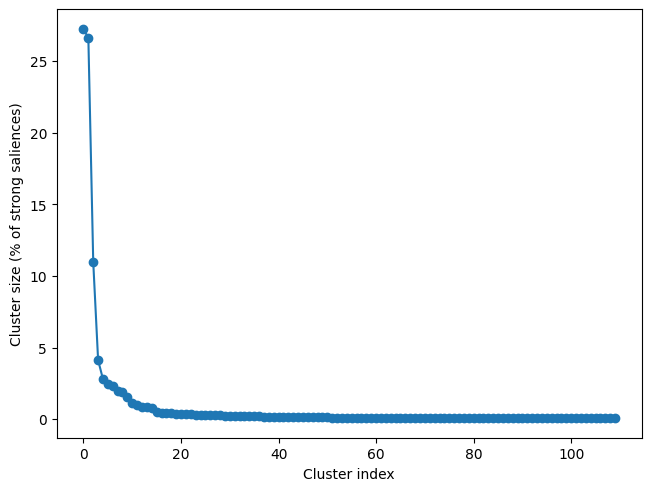

In [3]:
res.plot_cluster_sizes(lv_idx=0)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='N. vertices in cluster'>)

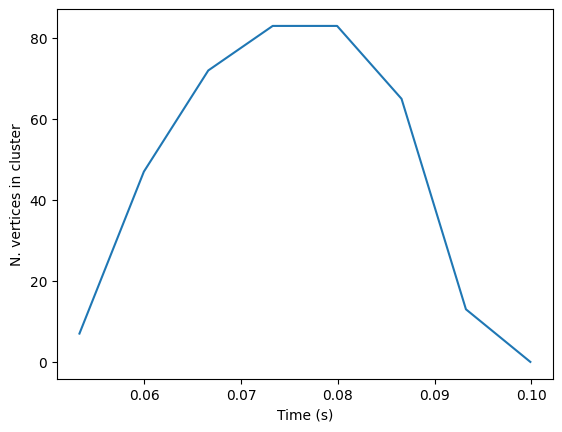

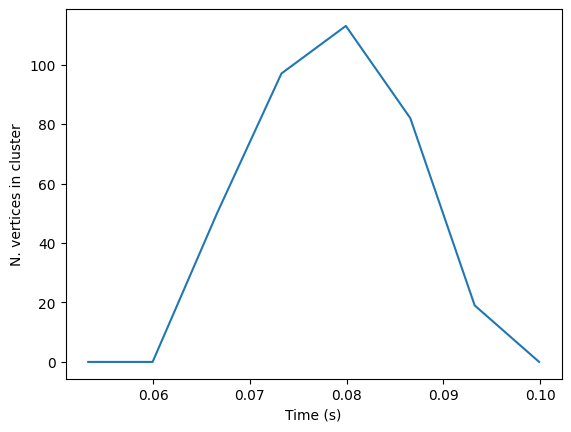

In [4]:
res.plot_cluster_nonspatial(lv_idx=0, cluster_idx=0)
res.plot_cluster_nonspatial(lv_idx=0, cluster_idx=1)

In [5]:
res.plot_cluster_spatial(lv_idx=0, cluster_idx=0)
res.plot_cluster_spatial(lv_idx=0, cluster_idx=1)

Using pyvistaqt 3d backend.
Using control points [0.         0.         0.01820838]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
Using control points [0.         0.         0.02423599]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installe